# PR Review Env: GRPO Training (Kaggle)

This notebook clones your GitHub repo, installs training dependencies, starts the OpenEnv server, runs GRPO training, and saves artifacts for submission evidence.

## 1) Runtime checks
Make sure Kaggle Notebook accelerator is set to **GPU**.

In [1]:
import os
import torch

print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('CUDA capability:', torch.cuda.get_device_capability(0))
else:
    print('No GPU detected. Enable GPU in Kaggle settings.')

CUDA available: True
GPU: Tesla T4
CUDA capability: (7, 5)


## 2) Clone your GitHub project
Replace `REPO_URL` with your uploaded repo URL.

In [2]:
REPO_URL = "https://github.com/mithilesh11705/Meta_3_1.git"
!git clone "$REPO_URL" repo
%cd repo

Cloning into 'repo'...
remote: Enumerating objects: 487, done.
remote: Counting objects: 100% (487/487), done.
remote: Compressing objects: 100% (352/352), done.
remote: Total 487 (delta 213), reused 401 (delta 127), pack-reused 0 (from 0)
Receiving objects: 100% (487/487), 505.64 KiB | 3.80 MiB/s, done.
Resolving deltas: 100% (213/213), done.
/kaggle/working/repo


## 3) Optional: Hugging Face token from Kaggle Secrets
Create a Kaggle secret named `HF_TOKEN` if your model needs auth.

In [3]:
try:
    from kaggle_secrets import UserSecretsClient
    token = UserSecretsClient().get_secret("HF_TOKEN")
    os.environ["HF_TOKEN"] = token
    print("HF_TOKEN loaded from Kaggle Secrets")
except Exception:
    print("HF_TOKEN not set (ok for public models)")

HF_TOKEN not set (ok for public models)


## 4) Install dependencies

In [4]:
!pip install -q -r requirements-train.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 5) Start OpenEnv server inside notebook

In [5]:
import subprocess
import time

# Important: avoid stdout=PIPE here, otherwise uvicorn logs can fill the pipe and block requests.
server = subprocess.Popen(
    ["python", "-m", "uvicorn", "server.app:app", "--host", "0.0.0.0", "--port", "7860"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.STDOUT,
)
time.sleep(6)
print("Server PID:", server.pid)
!curl -s http://127.0.0.1:7860/health

Server PID: 130
{"status":"ok","environment":"pr-review-env","version":"2.0.0","total_tasks":100,"active_sessions":0,"available_tasks":["easy","easy_1012","easy_1013","easy_1014","easy_1015","easy_1016","easy_1017","easy_1018","easy_1019","easy_1020","easy_1021","easy_1022","easy_1023","easy_1024","easy_1025","easy_1026","easy_1027","easy_1028","easy_1029","easy_1030","easy_1031","easy_1032","easy_1033","easy_1034","easy_1035","easy_1036","easy_1037","easy_1038","easy_1039","easy_1040","medium","medium_2045","medium_2046","medium_2047","medium_2048","medium_2049","medium_2050","medium_2051","medium_2052","medium_2053","medium_2054","medium_2055","medium_2056","medium_2057","medium_2058","medium_2059","medium_2060","medium_2061","medium_2062","medium_2063","medium_2064","medium_2065","medium_2066","medium_2067","medium_2068","medium_2069","medium_2070","medium_2071","medium_2072","medium_2073","medium_2074","medium_2075","medium_2076","medium_2077","medium_2078","hard","hard_3100","hard

## 6) Run GRPO training (updated stable config)
Uses your latest anti-collapse settings (`--no-strict-json-reward`, shorter completions, more generations) and hides noisy trainer keys in console output.

In [6]:
!mkdir -p artifacts/grpo_kaggle_run
!python train_grpo.py \
  --env-base-url http://127.0.0.1:7860 \
  --model-name Qwen/Qwen2.5-0.5B-Instruct \
  --num-samples 120 \
  --num-train-epochs 2 \
  --per-device-train-batch-size 1 \
  --gradient-accumulation-steps 4 \
  --num-generations 4 \
  --learning-rate 2e-5 \
  --episodes-per-task 1 \
  --max-episode-steps 3 \
  --eval-tasks-per-difficulty 1 \
  --env-timeout-seconds 120 \
  --env-max-retries 3 \
  --no-strict-json-reward \
  --parse-failure-reward 0.001 \
  --max-completion-length 64 \
  --max-new-tokens 64 \
  --output-dir artifacts/grpo_kaggle_run 2>&1 | tee artifacts/grpo_kaggle_run/training.log

2026-04-26 03:27:16.037627: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777174036.228530     140 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777174036.282545     140 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777174036.698390     140 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777174036.698441     140 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777174036.698445     140 computation_placer.cc:177] computation placer alr

## 7) View training outputs

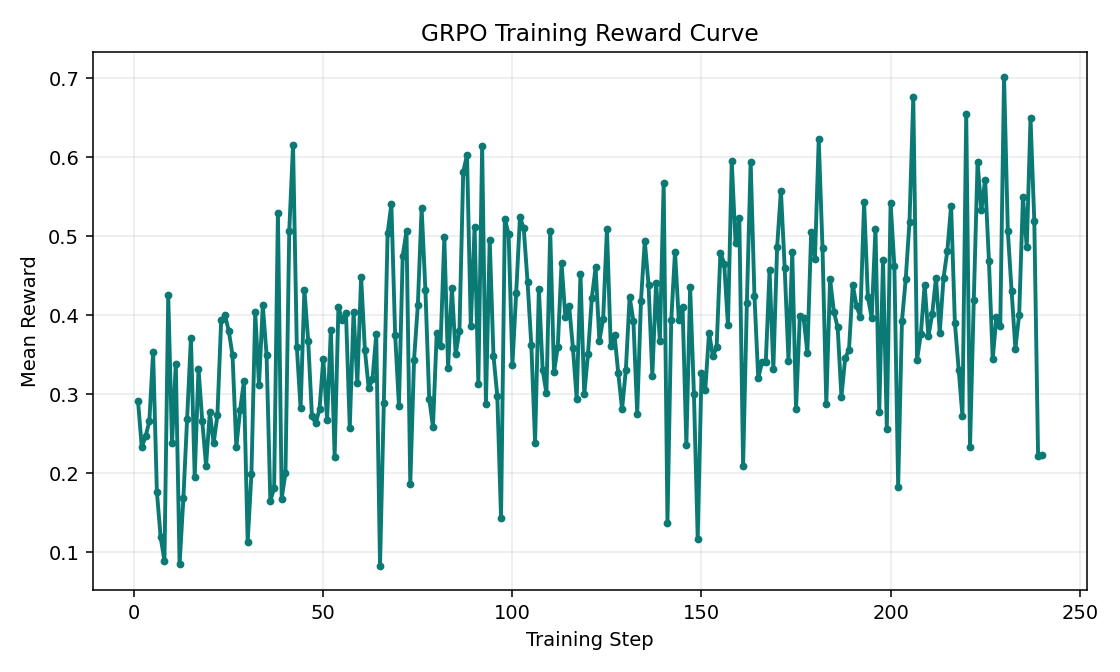

| Metric | Baseline | Trained |
|---|---:|---:|
| Easy Avg | 0.888 | 0.888 |
| Easy Latency-Adjusted Avg | 0.089 | 0.089 |
| Medium Avg | 0.888 | 0.888 |
| Medium Latency-Adjusted Avg | 0.089 | 0.089 |
| Hard Avg | 0.891 | 0.888 |
| Hard Latency-Adjusted Avg | 0.102 | 0.089 |
| Overall | 0.889 | 0.888 |
| Overall Latency-Adjusted | 0.093 | 0.089 |
| Mean Latency (s) | 16.524 | 17.030 |


{'baseline': {'easy_1021': 0.8878333333333334,
  'easy_1021_mean_latency_seconds': 16.9299472040002,
  'easy_1021_latency_adjusted': 0.08878333333333334,
  'medium_2049': 0.8878333333333334,
  'medium_2049_mean_latency_seconds': 16.458578211999793,
  'medium_2049_latency_adjusted': 0.08878333333333334,
  'hard_3122': 0.8911666666666668,
  'hard_3122_mean_latency_seconds': 16.183897618000174,
  'hard_3122_latency_adjusted': 0.10232635858235686,
  'easy_avg': 0.8878333333333334,
  'easy_latency_adjusted_avg': 0.08878333333333334,
  'medium_avg': 0.8878333333333334,
  'medium_latency_adjusted_avg': 0.08878333333333334,
  'hard_avg': 0.8911666666666668,
  'hard_latency_adjusted_avg': 0.10232635858235686,
  'overall': 0.8889444444444444,
  'overall_latency_adjusted': 0.09329767508300785,
  'mean_raw_reward': 0.8889444444444444,
  'mean_latency_seconds': 16.524141011333388,
  'mean_latency_adjusted_score': 0.09329767508300785},
 'after_training': {'easy_1031': 0.8878333333333334,
  'easy_103

In [7]:
from IPython.display import Image, Markdown, display
import json

display(Image(filename='artifacts/grpo_kaggle_run/plots/reward_curve.png'))
display(Markdown(open('artifacts/grpo_kaggle_run/logs/before_after.md', 'r', encoding='utf-8').read()))
summary = json.load(open('artifacts/grpo_kaggle_run/logs/training_summary.json', 'r', encoding='utf-8'))
summary

## 8) Export artifacts for download/submission

In [8]:
!zip -r grpo_kaggle_artifacts.zip artifacts/grpo_kaggle_run
!ls -lh grpo_kaggle_artifacts.zip

  adding: artifacts/grpo_kaggle_run/ (stored 0%)
  adding: artifacts/grpo_kaggle_run/logs/ (stored 0%)
  adding: artifacts/grpo_kaggle_run/logs/training_log_submission.csv (deflated 59%)
  adding: artifacts/grpo_kaggle_run/logs/reward_history.csv (deflated 69%)
  adding: artifacts/grpo_kaggle_run/logs/reward_components.csv (deflated 88%)
  adding: artifacts/grpo_kaggle_run/logs/training_summary.json (deflated 72%)
  adding: artifacts/grpo_kaggle_run/logs/before_after.md (deflated 57%)
  adding: artifacts/grpo_kaggle_run/logs/evaluation_baseline.csv (deflated 46%)
  adding: artifacts/grpo_kaggle_run/logs/evaluation_after_training.csv (deflated 52%)
  adding: artifacts/grpo_kaggle_run/plots/ (stored 0%)
  adding: artifacts/grpo_kaggle_run/plots/trainer_learning_rate_curve.png (deflated 13%)
  adding: artifacts/grpo_kaggle_run/plots/reward_curve.png (deflated 4%)
  adding: artifacts/grpo_kaggle_run/plots/trainer_grad_norm_curve.png (deflated 6%)
  adding: artifacts/grpo_kaggle_run/plots/t